<a href="https://colab.research.google.com/github/izzdizzy/ATAI/blob/main/agent_qwen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IT3103 Assignment 2 — Multimodal Agent with Qwen3-VL

**Agentic AI** — Build a visual **ReAct + Reflexion** agent.

> **Agent = LLM + Loop + Tools + Memory + Self-Correction**

This starter notebook gives you the scaffolding. Sections marked **`# TODO`** are yours to complete.

**Model:** `Qwen/Qwen3-VL-8B-Instruct` (4-bit). Fallback: `Qwen/Qwen3-VL-4B-Instruct` (Section 1).

**Tool calling is *native*:** you pass the tool JSON schemas to the chat template via `tools=`,
the model replies with a `<tool_call>{"name":...,"arguments":{...}}</tool_call>` block, and you
return each observation through the model's dedicated `role:"tool"` channel. (Qwen3-VL is trained
for this — you do **not** have to describe the tool format in prose.)

In [ ]:
import ctypes, glob, site
for _sp in site.getsitepackages():
    _hits = glob.glob(f"{_sp}/nvidia/**/libnvJitLink.so.13", recursive=True)
    if _hits:
        ctypes.CDLL(_hits[0], mode=ctypes.RTLD_GLOBAL)
        break

import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


## 0. Install dependencies

If prompted, restart the kernel after install.

In [ ]:
# Qwen3-VL needs a recent transformers; its processor also needs torchvision.
%pip install -q -U "transformers>=4.57.0" accelerate bitsandbytes pillow torchvision

In [ ]:
import torch, random, numpy as np

# Reproducibility.
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('WARNING: no GPU detected.')

GPU: Tesla T4


## 1. Load the model (4-bit)

We load `Qwen/Qwen3-VL-8B-Instruct` in **4-bit** (fits in ~7 GB VRAM). Qwen3-VL loads through
the generic `AutoModelForImageTextToText` class.

**If you get an out-of-memory (OOM) error**, set `USE_FALLBACK_4B = True` and re-run this cell.
State which model you used in your report — using the 4B fallback is fully accepted.

In [ ]:
from transformers import AutoModelForImageTextToText, AutoProcessor, BitsAndBytesConfig

USE_FALLBACK_4B = False  # set True if the 8B model OOMs on your GPU

MODEL_ID = "Qwen/Qwen3-VL-4B-Instruct" if USE_FALLBACK_4B else "Qwen/Qwen3-VL-8B-Instruct"
print('Loading', MODEL_ID)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.float16,
)

# Cap image resolution to control the number of vision tokens (keeps VRAM in check).
# Lower max_pixels if you OOM; raise it (carefully) if the model can't read fine detail.
MIN_PIXELS = 256 * 28 * 28
MAX_PIXELS = 1280 * 28 * 28
processor = AutoProcessor.from_pretrained(MODEL_ID, min_pixels=MIN_PIXELS, max_pixels=MAX_PIXELS)
print('Loaded. VRAM used (GB):', round(torch.cuda.memory_allocated()/1e9, 2))

Loading Qwen/Qwen3-VL-8B-Instruct


config.json:   0%|          | 0.00/1.47k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/67.8k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

[ERROR] `min_frames` is part of Qwen3VLVideoProcessorInitKwargs, but not documented. Make sure to add it to the docstring of the function in /usr/local/lib/python3.12/dist-packages/transformers/models/qwen3_vl/video_processing_qwen3_vl.py.
[ERROR] `max_frames` is part of Qwen3VLVideoProcessorInitKwargs, but not documented. Make sure to add it to the docstring of the function in /usr/local/lib/python3.12/dist-packages/transformers/models/qwen3_vl/video_processing_qwen3_vl.py.
Loaded. VRAM used (GB): 6.4


## 2. A single model call (helper)

`vlm_generate(messages)` runs one forward pass. `messages` follows the Qwen chat format,
where content items can be `{"type": "image", "image": <PIL.Image>}` or `{"type": "text", "text": ...}`.

We support **tools** via the processor's chat template (`tools=...`), which is how Qwen3-VL
exposes **native function calling**. Qwen3-VL's processor handles vision internally, so we pass
`tokenize=True, return_dict=True` to `apply_chat_template` and it embeds any images for us — no
separate `process_vision_info` step is needed.

In [ ]:
def vlm_generate(messages, tools=None, max_new_tokens=512):
    """Run one generation. Returns the assistant's raw text output."""
    inputs = processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, tools=tools,
        return_dict=True, return_tensors="pt",
    ).to(model.device)
    with torch.no_grad():
        generated = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    trimmed = generated[:, inputs["input_ids"].shape[1]:]
    out = processor.batch_decode(trimmed, skip_special_tokens=True)[0]
    return out.strip()

## 3. Part A — The task dataset (10 tasks)

Each task is `(image, question, answer)`. Here we **generate** a few synthetic images so the
notebook is self-contained; replace/extend these with your own images (charts, receipts,
photos). At least keep the `answer` as ground truth so your evaluator can score attempts.

The synthetic tasks below are deliberately simple. For full marks, add harder multi-step visual tasks that genuinely require tool calling, multiple loops and attempts.

10 tasks defined (add more for full marks).


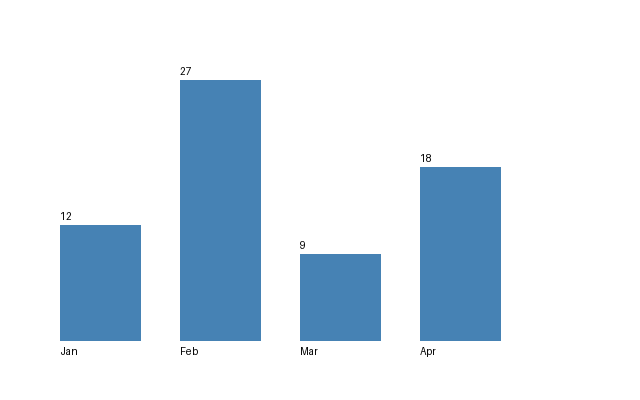

In [ ]:
from PIL import Image, ImageDraw, ImageFont

def _make_bar_chart(values, labels):
    W, H = 640, 400
    img = Image.new('RGB', (W, H), 'white')
    d = ImageDraw.Draw(img)
    base_y, max_v = 340, max(values)
    bw = W // (len(values) * 2)
    for i, (v, lab) in enumerate(zip(values, labels)):
        x = 60 + i * (bw + 40)
        h = int((v / max_v) * 260)
        d.rectangle([x, base_y - h, x + bw, base_y], fill='steelblue')
        d.text((x, base_y + 5), lab, fill='black')
        d.text((x, base_y - h - 15), str(v), fill='black')
    return img

def _make_receipt(items):
    W, H = 360, 420
    img = Image.new('RGB', (W, H), 'white')
    d = ImageDraw.Draw(img)
    d.text((20, 20), 'CAFE RECEIPT', fill='black')
    y = 60
    for name, price in items:
        d.text((20, y), name, fill='black')
        d.text((260, y), f'${price:.2f}', fill='black')
        y += 30
    return img

# --- Build 10 tasks (mix of charts + receipts). Extend with your own images. ---
TASKS = []

chart = _make_bar_chart([12, 27, 9, 18], ['Jan', 'Feb', 'Mar', 'Apr'])
TASKS.append(dict(image=chart,
                  question='What is the difference between the highest and lowest month?',
                  answer='18'))
TASKS.append(dict(image=chart,
                  question='What is the total across all four months?',
                  answer='66'))

receipt = _make_receipt([('Coffee', 4.50), ('Tea', 3.00), ('Cake', 6.20),
                         ('Juice', 5.00), ('Sandwich', 7.80)])
TASKS.append(dict(image=receipt,
                  question='What is the total of the beverage items (Coffee, Tea, Juice)?',
                  answer='12.50'))
TASKS.append(dict(image=receipt,
                  question='What is the grand total of all items?',
                  answer='26.50'))

# TODO: add 6 more tasks of your own (aim for genuinely multi-step visual reasoning).

# Additional multi-step visual reasoning tasks
# Task 5: Multi-step chart reading - find average
TASKS.append(dict(image=chart,
                  question='What is the average value across all four months?',
                  answer='16.5'))

# Task 6: Receipt - find most expensive item price
TASKS.append(dict(image=receipt,
                  question='What is the price of the most expensive item?',
                  answer='7.80'))

# Task 7: Receipt - calculate tip percentage
receipt2 = _make_receipt([('Latte', 4.80), ('Muffin', 3.50), ('Cookie', 2.20)])
TASKS.append(dict(image=receipt2,
                  question='If you pay with a 20 dollar bill, how much change do you get?',
                  answer='9.50'))

# Task 8: Chart - percentage calculation
chart2 = _make_bar_chart([25, 35, 20, 20], ['A', 'B', 'C', 'D'])
TASKS.append(dict(image=chart2,
                  question='What percentage of the total does category B represent?',
                  answer='35'))

# Task 9: Receipt - count items
receipt3 = _make_receipt([('Pen', 1.50), ('Notebook', 4.00), ('Eraser', 0.80), ('Ruler', 2.20)])
TASKS.append(dict(image=receipt3,
                  question='How many items are listed on this receipt?',
                  answer='4'))

# Task 10: Chart - ratio calculation
chart3 = _make_bar_chart([10, 20, 30, 40], ['Q1', 'Q2', 'Q3', 'Q4'])
TASKS.append(dict(image=chart3,
                  question='What is the ratio of Q4 to Q1 expressed as a number?',
                  answer='4'))


print(f'{len(TASKS)} tasks defined (add more for full marks).')
TASKS[0]['image']

## 4. Part A — Baseline (no tools, no loop)

Ask the model each question directly. This is your control to compare the agent against.

In [ ]:
def normalise(ans):
    """Loose normaliser so '18', '18.0', '$18' compare equal. Improve as needed."""
    s = str(ans).lower().strip().replace('$', '').replace(',', '')
    try:
        return str(round(float(s), 2))
    except ValueError:
        return s

def is_correct(pred, gold):
    return normalise(gold) in normalise(pred) or normalise(pred) == normalise(gold)

def baseline_answer(task):
    messages = [{
        'role': 'user',
        'content': [
            {'type': 'image', 'image': task['image']},
            {'type': 'text', 'text': task['question'] + ' Answer with just the number.'},
        ],
    }]
    return vlm_generate(messages, max_new_tokens=64)

# TODO: run baseline over all tasks, store predictions, and report accuracy.
baseline_correct = 0
for i, task in enumerate(TASKS):
    pred = baseline_answer(task)
    ok = is_correct(pred, task['answer'])
    baseline_correct += ok
    print(f"[{i}] pred={pred!r} gold={task['answer']!r} {'OK' if ok else 'X'}")
print(f'\nBaseline accuracy: {baseline_correct}/{len(TASKS)}')

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:944: UserWarning: inner dimension (4304) is not aligned for fast kernel with blocksize=64, falling back to slower implementation.
  warn(


[0] pred='18' gold='18' OK


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:944: UserWarning: inner dimension (4304) is not aligned for fast kernel with blocksize=64, falling back to slower implementation.
  warn(


[1] pred='60' gold='66' X
[2] pred='12.5' gold='12.50' OK
[3] pred='21.50' gold='26.50' X
[4] pred='12' gold='16.5' X
[5] pred='7.80' gold='7.80' OK
[6] pred='9.7' gold='9.50' X
[7] pred='35' gold='35' OK
[8] pred='4' gold='4' OK
[9] pred='4' gold='4' OK

Baseline accuracy: 6/10


## 5. Part B — Tools

Define your tools. Each tool is (1) a Python function and (2) a JSON schema the model sees.

Two tools are implemented for you as examples (`calculator`, `finish`). **You must implement
the visual tools** (`crop_region`, and at least one more, e.g. `zoom` or `read_text`).

In [ ]:
# ALTERED
import ast, operator

# ---- Safe calculator (do NOT use eval on untrusted input) ----
_OPS = {ast.Add: operator.add, ast.Sub: operator.sub, ast.Mult: operator.mul,
        ast.Div: operator.truediv, ast.Pow: operator.pow, ast.USub: operator.neg}
def _safe_eval(node):
    if isinstance(node, ast.Constant):
        return node.value
    if isinstance(node, ast.BinOp):
        return _OPS[type(node.op)](_safe_eval(node.left), _safe_eval(node.right))
    if isinstance(node, ast.UnaryOp):
        return _OPS[type(node.op)](_safe_eval(node.operand))
    raise ValueError('unsupported expression')

def calculator(expression: str):
    return _safe_eval(ast.parse(expression, mode='eval').body)

# ---- TODO: implement neccesary tools here.  ----
def crop_region(box):
    """box = [x1, y1, x2, y2] in pixels. Return a cropped PIL image."""
    # TODO: return current_image.crop(tuple(box))
    return current_image.crop(tuple(box))

def read_text(box=None):
    """Ask the VLM to transcribe text in a region (or whole image if box is None)."""
    # TODO: crop if box given, then call vlm_generate with a 'transcribe the text' prompt.
    global current_image
    if box is not None:
        cropped = current_image.crop(tuple(box))
        img_to_use = cropped
    else:
        img_to_use = current_image
    messages = [{
        'role': 'user',
        'content': [{'type': 'image', 'image': img_to_use}, {'type': 'text', 'text': 'Transcribe all visible text in this image. Return only the text.'}]}
    ]
    return vlm_generate(messages, max_new_tokens=256)



# JSON schemas the model sees (native function-calling format).
TOOLS = [
    {'type': 'function', 'function': {
        'name': 'crop_region', 'description': 'Crop the image to a box for closer inspection.',
        'parameters': {'type': 'object', 'properties': {
            'box': {'type': 'array', 'items': {'type': 'number'},
                    'description': '[x1,y1,x2,y2] pixel coordinates'}},
            'required': ['box']}}},
    {'type': 'function', 'function': {
        'name': 'read_text', 'description': 'Transcribe text visible in a region of the image.',
        'parameters': {'type': 'object', 'properties': {
            'box': {'type': 'array', 'items': {'type': 'number'}}},
            'required': []}}},
    {'type': 'function', 'function': {
        'name': 'calculator', 'description': 'Evaluate an arithmetic expression, e.g. "12+27".',
        'parameters': {'type': 'object', 'properties': {
            'expression': {'type': 'string'}}, 'required': ['expression']}}},
]

TOOL_FNS = {'crop_region': crop_region, 'read_text': read_text,
            'calculator': calculator}


## 6. Part B — The ReAct loop

Parse the model's tool call, execute the tool, feed the observation back, repeat until
`finish` or `max_steps`.

**Parsing note:** Qwen emits tool calls inside `<tool_call>...</tool_call>` tags containing
JSON like `{"name": ..., "arguments": {...}}`. A parser helper is provided; you must wire up
the loop and handle malformed calls gracefully. The robustness is graded.

**Native observations:** with native tool calling you return each tool result through a
`role:"tool"` message. A *text* result is
a plain string; an **image** result (from `crop_region`) can ride inside the tool message as
multimodal content — `{"role":"tool","content":[{"type":"text",...},{"type":"image","image":...}]}`. Feed a crop back as an image to the conversion (not a text
description of it).

In [16]:
# ALTERED
import json, re

current_image = None

SYSTEM_PROMPT = (
    'You are a visual analyst agent. Think step by step. Use the provided tools to inspect '
    'the image (crop/read), compute with the calculator, and then call finish(answer). '
    'Prefer cropping to read small details. Call exactly one tool per turn.'
)

def parse_tool_call(text):
    """Extract (name, args) from a Qwen tool-call string, or (None, None) if absent."""
    m = re.search(r'<tool_call>\s*(\{.*?\})\s*</tool_call>', text, re.DOTALL)
    if not m:
        return None, None
    try:
        call = json.loads(m.group(1))
        return call.get('name'), call.get('arguments', {})
    except json.JSONDecodeError:
        return None, None  # malformed — your loop should handle this

def react_agent(task, max_steps=6, verbose=True, system_prompt=None):
    global current_image
    current_image = task['image']
    trace = []

    prompt_to_use = system_prompt if system_prompt is not None else SYSTEM_PROMPT

    messages = [
        {'role': 'system', 'content': [{'type': 'text', 'text': prompt_to_use}]},  # FIX: list format
        {'role': 'user', 'content': [
            {'type': 'image', 'image': task['image']},
            {'type': 'text', 'text': task['question']}]},
    ]

    for step in range(max_steps):
        out = vlm_generate(messages, tools=TOOLS, max_new_tokens=384)
        name, args = parse_tool_call(out)

        # No tool call - model gave direct answer
        if name is None:
            trace.append(('step', step, out))
            match = re.search(r'(?:answer is|equals|result)[:\s]*([\d.]+)', out, re.IGNORECASE)
            if match:
                return match.group(1), trace
            # FIX: assistant content must be list format
            messages.append({'role': 'assistant', 'content': [{'type': 'text', 'text': out}]})
            continue

        # Execute the tool
        try:
            if name not in TOOL_FNS:
                obs = f'Error: Unknown tool "{name}"'
            else:
                tool_fn = TOOL_FNS[name]
                result = tool_fn(**args) if args else tool_fn()
                if hasattr(result, 'save'):  # PIL Image
                    obs = {'type': 'image', 'image': result}
                    current_image = result
                else:
                    obs = str(result)
        except Exception as e:
            obs = f'Error executing {name}: {str(e)}'

        trace.append((name, args, obs))
        if verbose:
            print(f'Step {step}: {name}({args}) -> {obs if not isinstance(obs, dict) else "[IMAGE]"}')

        # FIX: tool content must be list format
        if isinstance(obs, dict):
            tool_content = [obs]
        else:
            tool_content = [{'type': 'text', 'text': str(obs)}]

        messages.append({'role': 'tool', 'content': tool_content, 'tool_call_id': name})

        if name == 'finish':
            answer = args.get('answer', str(args))
            return answer, trace

    if verbose:
        print('Hit max steps without finishing')
    return None, trace

## 7. Part C — Reflexion

Wrap the ReAct agent in a retry loop with **verbal self-reflection**.

Flow: actor(ReAct inner loop) → evaluate → if fail, reflect → store reflection in
memory → retry with reflections in context. Reflections must be **specific**.

In [17]:
# ALTERED
def evaluate(pred, task):
    """Rule-based evaluator using the ground-truth answer."""
    return is_correct(pred, task["answer"])

def reflect(task, pred, trace):
    """Ask the model to produce a SPECIFIC reflection on why the attempt failed."""
    global current_image

    # Create a summary of the trace for context
    trace_summary = []
    for item in trace:
        if isinstance(item, tuple) and len(item) == 3:
            tool_name, args, obs = item
            if isinstance(obs, dict):
                obs_str = "[IMAGE]"
            else:
                obs_str = str(obs)[:100]  # Truncate long observations
            trace_summary.append(f"{tool_name}({args}) -> {obs_str}")
    trace_text = "\n".join(trace_summary)

    # Build reflection prompt
    reflection_prompt = f"""You made an attempt to answer this question but got it wrong.

    Question: {task["question"]}
    Your answer: {pred}
    Correct answer: {task["answer"]}

    Your action trace was:
    {trace_text}

    Look at the image again and explain specifically what went wrong.
    Did you misread a number? Crop the wrong region? Make a calculation error?
    Provide a brief (1-2 sentence) reflection on how to improve next time.
    Reflection:"""

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": current_image},
            {"type": "text", "text": reflection_prompt}
        ]
    }]

    reflection = vlm_generate(messages, max_new_tokens=128)
    return reflection.strip()

def reflexion_agent(task, max_attempts=3, verbose=True):
    memory = []
    for attempt in range(max_attempts):
        # 1. Inject memory into the system prompt locally
        if memory:
            memory_str = "\n".join([f"- {r}" for r in memory])
            current_prompt = SYSTEM_PROMPT + f"\n\nPast attempts failed. Learn from these reflections:\n{memory_str}"
        else:
            current_prompt = SYSTEM_PROMPT

        # 2. Run react_agent with the updated prompt
        ans, tr = react_agent(task, system_prompt=current_prompt)

        # 3. Evaluate
        if evaluate(ans, task):
            return ans, attempt + 1, memory

        # 4. Reflect and append to memory
        reflection = reflect(task, ans, tr)
        memory.append(reflection)

    return None, max_attempts, memory


## 8. Part C — Evaluate & compare

Produce the result comparison table: **Baseline vs ReAct vs Reflexion**, plus how accuracy improves
across retry attempts. Cope/Screenshot this table and paste it in your report.

In [18]:
# ALTERED
# Run all three approaches and collect results
print("Running Baseline...")
baseline_correct = 0
baseline_results = []
for task in TASKS:
    pred = baseline_answer(task)
    ok = is_correct(pred, task["answer"])
    baseline_correct += ok
    baseline_results.append((pred, ok))

print(f"Baseline: {baseline_correct}/{len(TASKS)}")

print("Running ReAct...")
react_correct = 0
react_results = []
for task in TASKS:
    pred, trace = react_agent(task, max_steps=6, verbose=False)
    if pred is None:
        ok = False
    else:
        ok = is_correct(pred, task["answer"])
    react_correct += ok
    react_results.append((pred, ok))

print(f"ReAct: {react_correct}/{len(TASKS)}")

print("Running Reflexion...")
reflexion_correct = 0
attempt_stats = {1: 0, 2: 0, 3: 0}
reflexion_results = []
for task in TASKS:
    pred, attempts, memory = reflexion_agent(task, max_attempts=3, verbose=False)
    if pred is None:
        ok = False
    else:
        ok = is_correct(pred, task["answer"])
    if ok:
        reflexion_correct += 1
        attempt_stats[attempts] += 1
    reflexion_results.append((pred, ok, attempts))

print(f"Reflexion: {reflexion_correct}/{len(TASKS)}")

# Print comparison table
print("\n" + "="*50)
print("RESULTS COMPARISON TABLE")
print("="*50)
print(f"{'Approach':<15} {'Accuracy':<10}")
print("-" * 30)
print(f"{'Baseline':<15} {baseline_correct}/{len(TASKS):<10}")
print(f"{'ReAct':<15} {react_correct}/{len(TASKS):<10}")
print(f"{'Reflexion':<15} {reflexion_correct}/{len(TASKS):<10}")
print("-" * 30)
print(f"Reflexion breakdown by attempt:")
print(f"  Attempt 1: {attempt_stats[1]} tasks")
print(f"  Attempt 2: {attempt_stats[2]} tasks")
print(f"  Attempt 3: {attempt_stats[3]} tasks")
print("="*50)


Running Baseline...
Baseline: 6/10
Running ReAct...
ReAct: 1/10
Running Reflexion...
Step 0: read_text({'box': [78, 494, 210, 562]}) -> The image contains no visible text.
Step 1: crop_region({'box': [70, 484, 220, 875]}) -> [IMAGE]
Step 2: crop_region({'box': [78, 149, 789, 856]}) -> [IMAGE]
Step 3: crop_region({'box': [78, 149, 789, 859]}) -> [IMAGE]
Step 4: crop_region({'box': [78, 143, 789, 856]}) -> [IMAGE]
Step 5: crop_region({'box': [78, 143, 800, 850]}) -> [IMAGE]
Hit max steps without finishing
Step 0: read_text({'box': [78, 494, 210, 562]}) -> The image contains no visible text.
Step 1: crop_region({'box': [70, 486, 220, 875]}) -> [IMAGE]
Step 2: crop_region({'box': [78, 149, 789, 833]}) -> [IMAGE]
Step 3: crop_region({'box': [70, 143, 300, 850]}) -> [IMAGE]
Step 4: crop_region({'box': [70, 137, 390, 856]}) -> [IMAGE]
Step 5: crop_region({'box': [70, 143, 800, 850]}) -> [IMAGE]
Hit max steps without finishing
Step 0: read_text({'box': [78, 494, 210, 562]}) -> The image contai

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU


Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

In [19]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

,Registration State,Violation Description,count
0,CA,Double Parking,50176
1,NJ,No Parking,50144
2,NY,Bus Stop,50277
3,TX,Expired Meter,50275


In [20]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas


,Registration State,Violation Description,count
0,CA,No Parking,50266
1,NJ,Bus Stop,50353
2,NY,Fire Hydrant,50454
3,TX,Expired Meter,50381


In [21]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas


,Registration State,Violation Description,count
0,CA,Fire Hydrant,50096
1,NJ,Double Parking,50347
2,NY,Double Parking,50149
3,TX,Double Parking,50547


In [22]:
import os
os.makedirs('data', exist_ok=True)

# Save all task images to the data folder
for i, task in enumerate(TASKS):
    task['image'].save(f'data/task_{i+1}.png')

# Zip and download the folder
!zip -r data_folder.zip data
from google.colab import files
files.download('data_folder.zip')

  adding: data/ (stored 0%)
  adding: data/task_6.png (deflated 25%)
  adding: data/task_8.png (deflated 42%)
  adding: data/task_9.png (deflated 27%)
  adding: data/task_5.png (deflated 38%)
  adding: data/task_1.png (deflated 38%)
  adding: data/task_2.png (deflated 38%)
  adding: data/task_7.png (deflated 28%)
  adding: data/task_3.png (deflated 25%)
  adding: data/task_4.png (deflated 25%)
  adding: data/task_10.png (deflated 39%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Report checklist (Part D)

Before you submit, make sure your `report.pdf` covers:

- [ ] Which model you used (8B or 4B) + setup (quantisation, `max_pixels`, OOM handling)
- [ ] The task dataset (10 tasks) (loop, tools, memory, evaluator)
- [ ] Tool design justification
- [ ] >= 3 documented failure cases with traces + whether ReAct/Reflexion fixed them
- [ ] Critical reflection: where did the small model struggle? Can small models reason & act?
- [ ] Results table: Baseline vs ReAct vs Reflexion

**Reminder:** you are graded on agent **engineering and analysis**, not on beating a benchmark.
Do **not** hard-code answers to the tasks.